In [ ]:
# 1. 환경 세팅 (가장 먼저 실행)
!pip install -q transformers timm inflect
!wget -q -O sample_test.jpg http://images.cocodataset.org/val2017/000000039769.jpg

import torch
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from transformers import (
    AutoProcessor, AutoModelForZeroShotObjectDetection,
    OwlViTProcessor, OwlViTForObjectDetection
)

In [ ]:
# 2. 디바이스 및 이미지 준비
device = "cuda" if torch.cuda.is_available() else "cpu"
image = Image.open("sample_test.jpg").convert("RGB")
THRESHOLD = 0.2

# ==========================================
# 3. 모델 로드
# ==========================================
print("Loading Grounding DINO...")
gdino_processor = AutoProcessor.from_pretrained("IDEA-Research/grounding-dino-tiny")
gdino_model = AutoModelForZeroShotObjectDetection.from_pretrained("IDEA-Research/grounding-dino-tiny").to(device)

print("Loading OWL-ViT...")
owl_processor = OwlViTProcessor.from_pretrained("google/owlvit-base-patch32")
owl_model = OwlViTForObjectDetection.from_pretrained("google/owlvit-base-patch32").to(device)

Loading Grounding DINO...


Loading weights:   0%|          | 0/990 [00:00<?, ?it/s]

Loading OWL-ViT...


Loading weights:   0%|          | 0/412 [00:00<?, ?it/s]

OwlViTForObjectDetection LOAD REPORT from: google/owlvit-base-patch32
Key                                         | Status     |  | 
--------------------------------------------+------------+--+-
owlvit.text_model.embeddings.position_ids   | UNEXPECTED |  | 
owlvit.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# ==========================================
# 4. 쿼리 설정 및 추론 (수정본)
# ==========================================
# 핵심: 모델별 쿼리 입력 방식 차이
queries_list = ["cat", "remote control", "blanket"] # OWL-ViT용
queries_str = "cat . remote control . blanket ."   # Grounding DINO용

# (1) Grounding DINO 추론 및 후처리
inputs_gdino = gdino_processor(images=image, text=queries_str, return_tensors="pt").to(device)
with torch.no_grad():
    outputs_gdino = gdino_model(**inputs_gdino)

results_gdino_raw = gdino_processor.post_process_grounded_object_detection(
    outputs_gdino, inputs_gdino.input_ids, target_sizes=[image.size[::-1]]
)[0]

results_gdino = {"scores": [], "labels": [], "boxes": []}
# FutureWarning 해결: 버전 호환성을 위해 text_labels가 있으면 우선 사용
labels_key = "text_labels" if "text_labels" in results_gdino_raw else "labels"

for score, label, box in zip(results_gdino_raw["scores"], results_gdino_raw[labels_key], results_gdino_raw["boxes"]):
    if score > THRESHOLD:
        results_gdino["scores"].append(score)
        results_gdino["labels"].append(label)
        results_gdino["boxes"].append(box)

# (2) OWL-ViT 추론 및 후처리
inputs_owl = owl_processor(text=[queries_list], images=image, return_tensors="pt").to(device)
with torch.no_grad():
    outputs_owl = owl_model(**inputs_owl)

# AttributeError 해결: image_processor 내부의 함수를 호출
results_owl = owl_processor.image_processor.post_process_object_detection(
    outputs=outputs_owl, target_sizes=[image.size[::-1]], threshold=THRESHOLD
)[0]

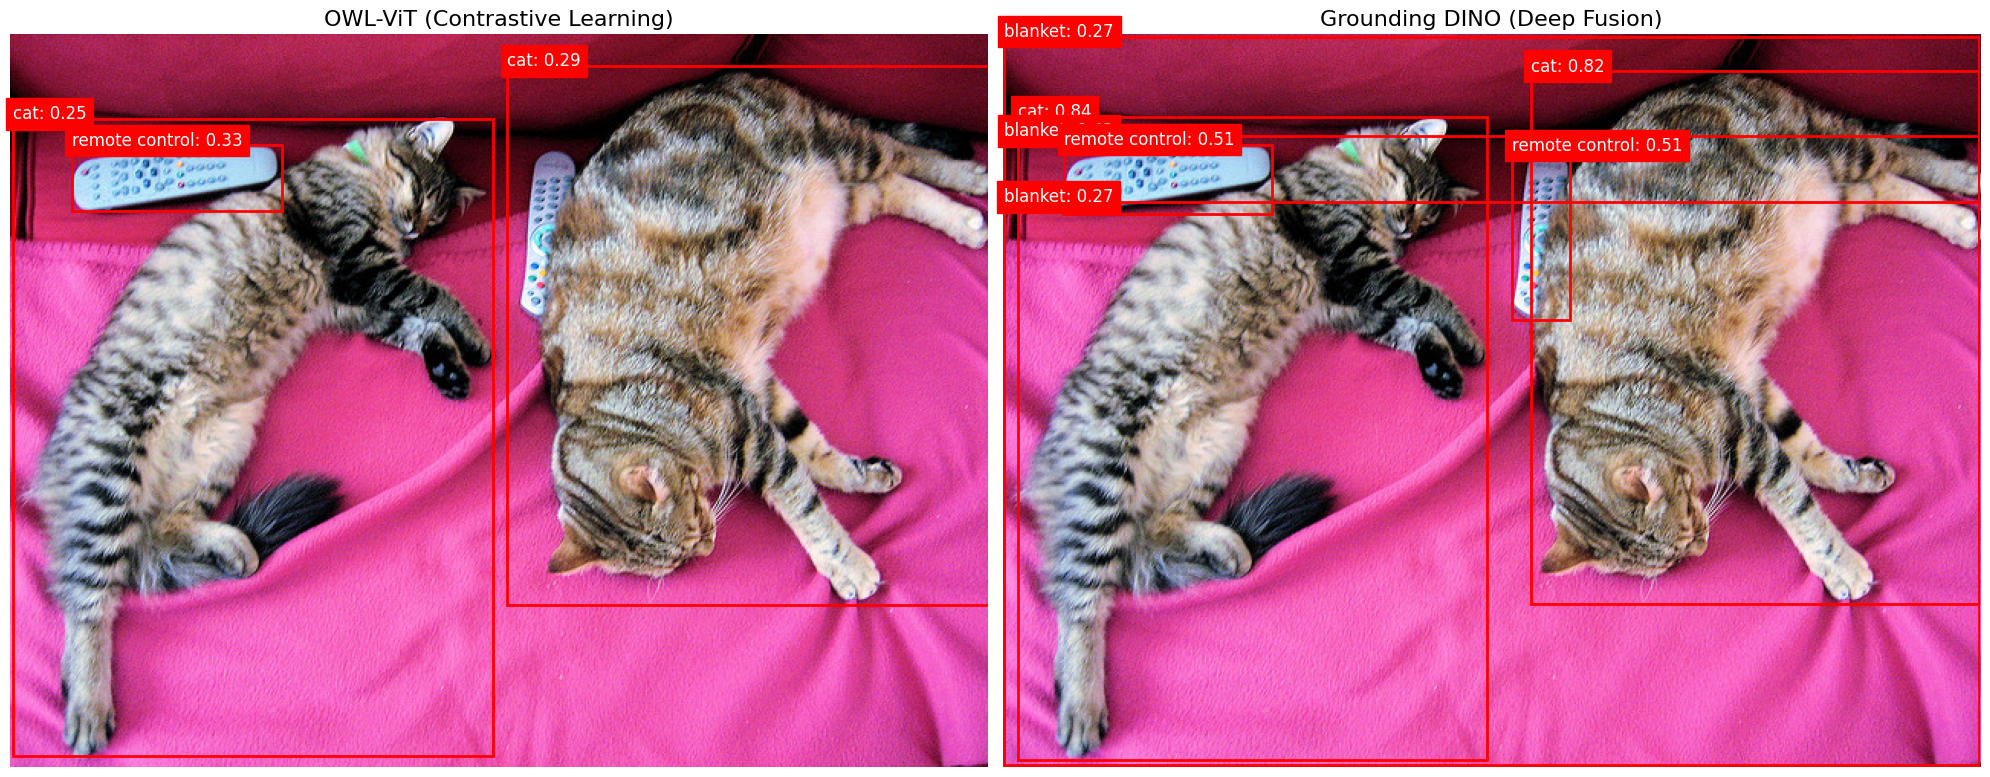

In [ ]:
# ==========================================
# 5. 좌우 비교 시각화 (A/B Test) - 이전과 동일
# ==========================================
fig, axs = plt.subplots(1, 2, figsize=(20, 10))

def draw_boxes(ax, results, title, is_owl=False):
    ax.imshow(image)
    ax.set_title(title, fontsize=16)
    ax.axis('off')

    for score, label_idx, box in zip(results["scores"], results["labels"], results["boxes"]):
        box = box.cpu().numpy()
        # OWL-ViT는 label이 index로 나오므로 문자열 매핑 필요
        label_text = queries_list[label_idx] if is_owl else label_idx

        rect = patches.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1],
                                 linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        ax.text(box[0], box[1], f"{label_text}: {score:.2f}", color='white', backgroundcolor='red', fontsize=12)

# 그리기
draw_boxes(axs[0], results_owl, "OWL-ViT (Contrastive Learning)", is_owl=True)
draw_boxes(axs[1], results_gdino, "Grounding DINO (Deep Fusion)", is_owl=False)

plt.tight_layout()
plt.show()

In [ ]:
import time
import torch
import torchvision.ops as ops

# 1. IoU 계산 핵심 함수 (PyTorch 내장 기능 활용)
def evaluate_iou(pred_boxes, gt_boxes):
    """
    pred_boxes: Tensor of shape (N, 4) [x1, y1, x2, y2]
    gt_boxes: Tensor of shape (M, 4) [x1, y1, x2, y2]
    반환값: N x M 크기의 IoU 매트릭스
    """
    # 텐서 타입 확인 및 변환
    if not isinstance(pred_boxes, torch.Tensor):
        pred_boxes = torch.tensor(pred_boxes, dtype=torch.float)
    if not isinstance(gt_boxes, torch.Tensor):
        gt_boxes = torch.tensor(gt_boxes, dtype=torch.float)

    # torchvision.ops.box_iou를 통해 모든 조합의 IoU를 한 번에 계산
    iou_matrix = ops.box_iou(pred_boxes, gt_boxes)
    return iou_matrix

# 2. 속도 측정 및 추론 로직 (예시 구조)
def measure_inference(model, inputs, is_gdino=True):
    # GPU 동기화를 해야 정확한 시간 측정이 가능 (원칙)
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start_time = time.time()

    with torch.no_grad():
        if is_gdino:
            outputs = model(**inputs)
        else:
            outputs = model(**inputs) # OWL-ViT

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    inference_time = time.time() - start_time
    return outputs, inference_time

In [ ]:
import json
import requests
from PIL import Image
from io import BytesIO

# ==========================================
# 1. LVIS Validation JSON 다운로드 및 로드
# ==========================================
import json

print("Downloading LVIS Validation JSON zip...")
# 원칙: 공식 배포 형태인 zip 파일을 다운로드 후 압축 해제
!wget -q -O lvis_v1_val.json.zip https://dl.fbaipublicfiles.com/LVIS/lvis_v1_val.json.zip
!unzip -q -o lvis_v1_val.json.zip

print("Parsing JSON...")
with open("lvis_v1_val.json", "r") as f:
    lvis_data = json.load(f)

# 카테고리 ID -> 이름 딕셔너리 생성 (언더바를 공백으로 변환)
category_dict = {cat['id']: cat['name'].replace('_', ' ') for cat in lvis_data['categories']}

# 이미지 ID -> 어노테이션 리스트 매핑
ann_dict = {}
for ann in lvis_data['annotations']:
    img_id = ann['image_id']
    if img_id not in ann_dict:
        ann_dict[img_id] = []
    ann_dict[img_id].append(ann)

print("JSON Parsing Complete!")

Parsing JSON...
JSON Parsing Complete!


In [ ]:
# ==========================================
# 2. 평가 보조 함수 (좌표 변환 및 평가)
# ==========================================
def xywh_to_xyxy(boxes):
    """LVIS [x, y, w, h] 포맷을 [x1, y1, x2, y2] 텐서로 변환"""
    boxes_tensor = torch.tensor(boxes, dtype=torch.float)
    if len(boxes_tensor) == 0:
        return torch.empty((0, 4))
    x1 = boxes_tensor[:, 0]
    y1 = boxes_tensor[:, 1]
    x2 = x1 + boxes_tensor[:, 2]
    y2 = y1 + boxes_tensor[:, 3]
    return torch.stack((x1, y1, x2, y2), dim=1)

def evaluate_iou(pred_boxes, gt_boxes):
    if len(pred_boxes) == 0 or len(gt_boxes) == 0:
        return torch.tensor(0.0)
    iou_matrix = ops.box_iou(pred_boxes, gt_boxes)
    # 가장 잘 매칭된 박스의 평균 IoU 계산
    max_ious, _ = iou_matrix.max(dim=0)
    return max_ious.mean().item()

def measure_inference(model, inputs):
    if torch.cuda.is_available(): torch.cuda.synchronize()
    start_time = time.time()

    with torch.no_grad():
        outputs = model(**inputs)

    if torch.cuda.is_available(): torch.cuda.synchronize()
    return outputs, time.time() - start_time

In [ ]:
lvis_data['images'][49]

{'date_captured': '2013-11-18 12:00:34',
 'neg_category_ids': [602, 967, 283, 127, 1164, 30, 704, 97],
 'id': 356427,
 'license': 3,
 'height': 427,
 'width': 640,
 'flickr_url': 'http://farm4.staticflickr.com/3053/2634837936_186c01f72b_z.jpg',
 'coco_url': 'http://images.cocodataset.org/val2017/000000356427.jpg',
 'not_exhaustive_category_ids': [1055]}

In [ ]:
unique_categories

['backpack', 'tag', 'shoe', 'plastic bag', 'streetlight', 'jean']

In [ ]:
# ==========================================
# 3. 평가 파이프라인 루프
# ==========================================
num_samples = 50
results_log = {"GDINO_time": [], "GDINO_iou": [], "OWL_time": [], "OWL_iou": []}

for i, img_info in enumerate(lvis_data['images'][:num_samples]):
    print(f"\n--- Processing Image {i+1}/{num_samples} ---")

    # 1. 이미지 및 정답(GT) 로드
    img_url = img_info['coco_url']
    response = requests.get(img_url)
    image = Image.open(BytesIO(response.content)).convert("RGB")

    img_id = img_info['id']
    annotations = ann_dict.get(img_id, [])

    if not annotations:
        print("No annotations found. Skipping.")
        continue

    # 해당 이미지에 존재하는 객체 이름들과 GT 좌표 추출
    gt_boxes_xywh = [ann['bbox'] for ann in annotations]
    gt_boxes = xywh_to_xyxy(gt_boxes_xywh)

    unique_categories = list(set([category_dict[ann['category_id']] for ann in annotations]))

    # 모델 입력용 쿼리 포맷팅
    queries_list = unique_categories # OWL-ViT용
    queries_str = " . ".join(unique_categories) + " ." # Grounding DINO용

    # 공통 임계값 설정
    SHARED_THRESHOLD = 0.2

    # ==========================================
    # [Grounding DINO 평가]
    # ==========================================
    inputs_gdino = gdino_processor(images=image, text=queries_str, return_tensors="pt").to(device)
    out_gdino, t_gdino = measure_inference(gdino_model, inputs_gdino)

    res_gdino = gdino_processor.post_process_grounded_object_detection(
        out_gdino, inputs_gdino.input_ids, target_sizes=[image.size[::-1]]
    )[0]

    # 공통 임계값 적용
    gdino_pred_boxes = [box for score, box in zip(res_gdino["scores"], res_gdino["boxes"]) if score > SHARED_THRESHOLD]
    gdino_pred_boxes = torch.stack(gdino_pred_boxes) if gdino_pred_boxes else torch.empty((0, 4))

    iou_gdino = evaluate_iou(gdino_pred_boxes.cpu(), gt_boxes)
    results_log["GDINO_time"].append(t_gdino)
    results_log["GDINO_iou"].append(iou_gdino)

    # ==========================================
    # [OWL-ViT 평가]
    # ==========================================
    # 프롬프트 엔지니어링은 유지 (모델 아키텍처 특성 반영)
    queries_list_owl = [f"a photo of a {cat}" for cat in unique_categories]
    inputs_owl = owl_processor(text=[queries_list_owl], images=image, return_tensors="pt").to(device)
    out_owl, t_owl = measure_inference(owl_model, inputs_owl)

    # 공통 임계값 적용
    res_owl = owl_processor.image_processor.post_process_object_detection(
        outputs=out_owl, target_sizes=[image.size[::-1]], threshold=SHARED_THRESHOLD
    )[0]

    owl_pred_boxes = res_owl["boxes"].cpu()
    iou_owl = evaluate_iou(owl_pred_boxes, gt_boxes)

    results_log["OWL_time"].append(t_owl)
    results_log["OWL_iou"].append(iou_owl)

    print(f"Categories: {queries_list}")
    print(f"GDINO -> Time: {t_gdino:.3f}s | Avg IoU: {iou_gdino:.3f}")
    print(f"OWL   -> Time: {t_owl:.3f}s | Avg IoU: {iou_owl:.3f}")

In [ ]:
# ==========================================
# 4. 최종 결과 요약
# ==========================================
print("\n========== FINAL RESULTS ==========")
print(f"Grounding DINO - Avg Time: {sum(results_log['GDINO_time'])/num_samples:.3f}s, Avg IoU: {sum(results_log['GDINO_iou'])/num_samples:.3f}")
print(f"OWL-ViT        - Avg Time: {sum(results_log['OWL_time'])/num_samples:.3f}s, Avg IoU: {sum(results_log['OWL_iou'])/num_samples:.3f}")


========== FINAL RESULTS ==========
Grounding DINO - Avg Time: 0.524s, Avg IoU: 0.659
OWL-ViT        - Avg Time: 0.055s, Avg IoU: 0.417


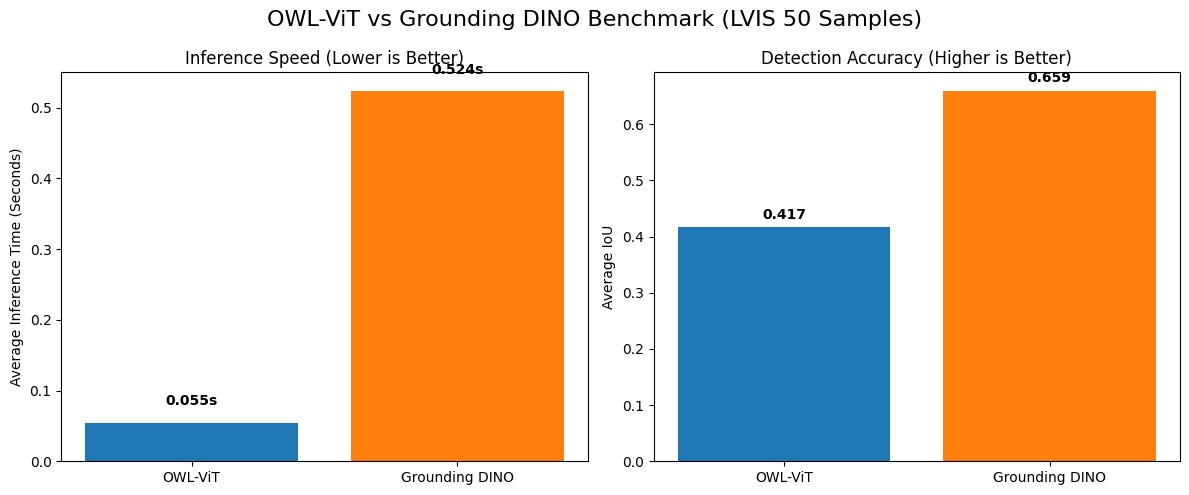

In [ ]:
# ==========================================
# 5. 모델 성능 비교 시각화 (속도 vs 정확도)
# ==========================================
import matplotlib.pyplot as plt
import numpy as np

# 평균값 계산
avg_gdino_time = np.mean(results_log['GDINO_time'])
avg_gdino_iou = np.mean(results_log['GDINO_iou'])
avg_owl_time = np.mean(results_log['OWL_time'])
avg_owl_iou = np.mean(results_log['OWL_iou'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 1. 속도 비교 (낮을수록 좋음)
bars1 = ax1.bar(['OWL-ViT', 'Grounding DINO'], [avg_owl_time, avg_gdino_time], color=['#1f77b4', '#ff7f0e'])
ax1.set_ylabel('Average Inference Time (Seconds)')
ax1.set_title('Inference Speed (Lower is Better)')
for bar in bars1:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.3f}s', ha='center', va='bottom', fontweight='bold')

# 2. 정확도 비교 (높을수록 좋음)
bars2 = ax2.bar(['OWL-ViT', 'Grounding DINO'], [avg_owl_iou, avg_gdino_iou], color=['#1f77b4', '#ff7f0e'])
ax2.set_ylabel('Average IoU')
ax2.set_title('Detection Accuracy (Higher is Better)')
for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.3f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('OWL-ViT vs Grounding DINO Benchmark (LVIS 50 Samples)', fontsize=16)
plt.tight_layout()
plt.show()